<>:83: SyntaxWarning: invalid escape sequence '\s'
<>:83: SyntaxWarning: invalid escape sequence '\s'
C:\Users\MSI MODERN\AppData\Local\Temp\ipykernel_12940\2066310249.py:83: SyntaxWarning: invalid escape sequence '\s'
  ax3.plot(x, y, label=r"$\mu=$" + str(i) + ", $\sigma=1$")


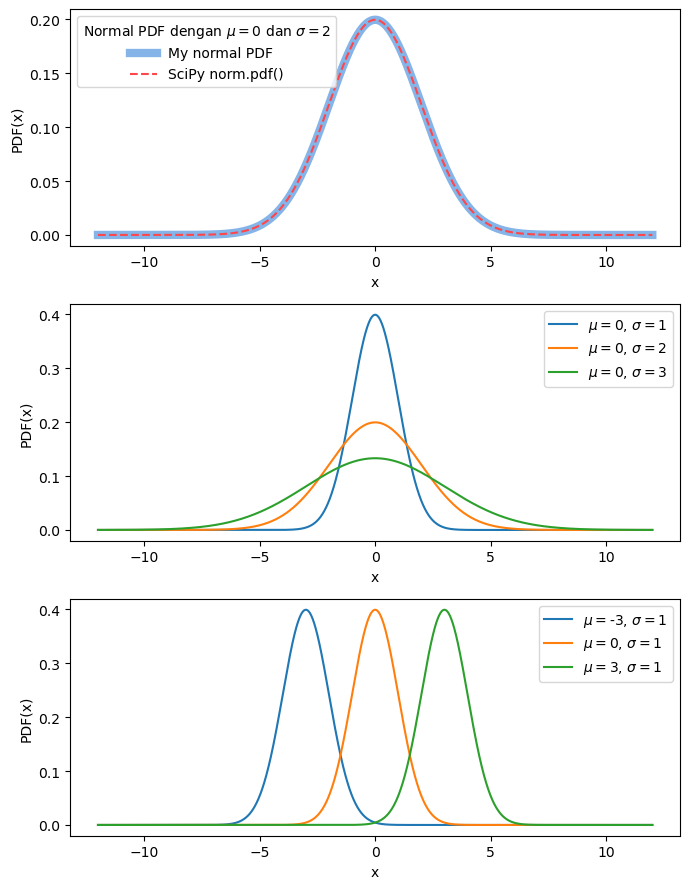

In [10]:
from scipy.stats import norm
# SciPy (stats module): digunakan untuk statistika, di sini untuk distribusi normal (Gaussian)

import matplotlib.pyplot as plt
# Matplotlib: library untuk membuat grafik dan visualisasi data

import numpy as np
# NumPy: library untuk komputasi numerik dan manipulasi array


def normal_pdf(x, mean, std):
    # fungsi untuk menghitung probability density function (PDF) distribusi normal

    return 1/(np.sqrt(2*np.pi*std**2)) * np.exp(-0.5*((x - mean)**2)/(std**2))
    # rumus matematika distribusi normal (Gaussian PDF)


x = np.arange(-12, 12, 0.001)
# membuat array nilai x dari -12 sampai 12 dengan interval kecil


pdf1 = normal_pdf(x, mean=0, std=2)
# menghitung PDF normal menggunakan fungsi buatan sendiri

pdf2 = norm.pdf(x, loc=0, scale=2)
# menghitung PDF normal menggunakan SciPy (fungsi siap pakai)


fig = plt.figure(figsize=(7,9))
# membuat canvas figure dengan ukuran 7x9 inci


ax1 = fig.add_subplot(3, 1, 1)
# membuat subplot pertama dari 3 baris 1 kolom

ax1.plot(x, pdf1, color='#84b4e8', linestyle="-", linewidth=6, label="My normal PDF")
# plot PDF hasil fungsi manual

ax1.plot(x, pdf2, color='#ff464a', linestyle="--", label="SciPy norm.pdf()")
# plot PDF dari SciPy untuk dibandingkan

ax1.set_xlabel("x")
# memberi label sumbu x

ax1.set_ylabel("PDF(x)")
# memberi label sumbu y

ax1.legend(title=r"Normal PDF dengan $\mu=0$ dan $\sigma=2$")
# menampilkan legenda dengan judul


ax2 = fig.add_subplot(3, 1, 2)
# subplot kedua

for i in [1, 2, 3]:
    # looping nilai standar deviasi

    y = normal_pdf(x, 0, i)
    # menghitung PDF untuk setiap nilai sigma

    ax2.plot(x, y, label=r"$\mu=0$, $\sigma=$" + str(i))
    # plot kurva distribusi

ax2.set_xlabel("x")
# label sumbu x subplot 2

ax2.set_ylabel("PDF(x)")
# label sumbu y subplot 2

ax2.legend()
# menampilkan legenda subplot 2


ax3 = fig.add_subplot(3, 1, 3)
# subplot ketiga

for i in [-3, 0, 3]:
    # looping nilai mean

    y = normal_pdf(x, i, 1)
    # menghitung PDF dengan sigma tetap 1

    ax3.plot(x, y, label=r"$\mu=$" + str(i) + ", $\sigma=1$")
    # plot kurva distribusi

ax3.set_xlabel("x")
# label sumbu x subplot 3

ax3.set_ylabel("PDF(x)")
# label sumbu y subplot 3

ax3.legend()
# menampilkan legenda subplot 3


fig.tight_layout()
# merapikan layout agar tidak tumpang tindih

In [11]:
from scipy.stats import norm
# SciPy stats: menyediakan fungsi distribusi probabilitas, di sini untuk distribusi normal

import numpy as np
# NumPy: digunakan untuk operasi numerik dan array

from scipy import special
# SciPy special: menyediakan fungsi matematika khusus seperti erf (error function)

from scipy import integrate
# SciPy integrate: digunakan untuk integrasi numerik (trapezoid, Simpson, dll)


def integrate_normal(x1, x2, mu, sigma):
    # fungsi untuk menghitung probabilitas distribusi normal secara analitik

    sup = 0.5 * (
        special.erf((x2 - mu) / (sigma * np.sqrt(2))) -
        special.erf((x1 - mu) / (sigma * np.sqrt(2)))
    )
    # rumus integral distribusi normal menggunakan fungsi error (erf)

    return sup
    # mengembalikan hasil probabilitas


my_mu = 0
# mean (μ) distribusi normal

my_sigma = 1
# standar deviasi (σ) distribusi normal


my_x1 = 0
# batas bawah integrasi

my_x2 = my_sigma
# batas atas integrasi (σ = 1)


# nilai teoritis probabilitas dari 0 sampai 1 untuk N(0,1)
my_sup = integrate_normal(x1=my_x1, x2=my_x2, mu=my_mu, sigma=my_sigma)
# menghitung hasil analitik menggunakan fungsi erf


x = np.arange(my_x1, my_x2, 0.0001)
# membuat grid x untuk integrasi numerik

y = norm.pdf(x, loc=my_mu, scale=my_sigma)
# menghitung PDF normal pada titik x menggunakan SciPy


sup_trapz = integrate.trapezoid(y, x)
# menghitung integral numerik menggunakan metode trapezoid

sup_simps = integrate.simpson(y, x)
# menghitung integral numerik menggunakan metode Simpson


print("Solution Using erf: {:.9f}".format(my_sup))
# menampilkan hasil analitik (erf)

print("Using the trapezoidal rule, trapz: {:.10f}".format(sup_trapz))
# menampilkan hasil integrasi trapezoid

print("Using the composite Simpson rule, simps: {:.10f}".format(sup_simps))
# menampilkan hasil integrasi Simpson

Solution Using erf: 0.341344746
Using the trapezoidal rule, trapz: 0.3413205476
Using the composite Simpson rule, simps: 0.3413205478


Sample mean equal to -0.0061
Sample standard deviation equal to 1.0005


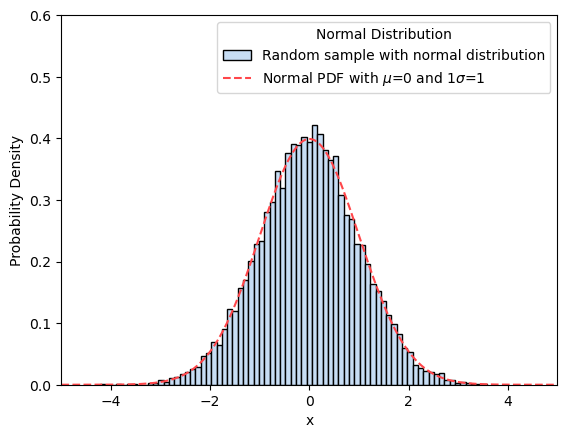

In [47]:
import numpy as np
# NumPy: library untuk komputasi numerik dan pengolahan array

from scipy.stats import norm
# SciPy stats: menyediakan fungsi distribusi statistik, termasuk distribusi normal

import matplotlib.pyplot as plt
# Matplotlib: digunakan untuk membuat visualisasi data (grafik)


mu = 0 # mean 
# mean (μ): nilai rata-rata dari distribusi normal

sigma = 1 # standard deviation
# standar deviasi (σ): ukuran sebaran data dari mean

normal_sample = np.random.normal(mu, sigma, 15000)
# menghasilkan 15000 data acak dari distribusi normal N(μ, σ)


# plot the histogram of the sample distribution
fig, ax = plt.subplots()
# membuat figure dan axis untuk plotting

ax.hist(normal_sample, bins='auto', density=True, color='#c7ddf4', edgecolor='#000000', label='Random sample with normal distribution')
# membuat histogram dari data sampel (distribusi empiris dari data acak)


# probability density function
x = np.arange(-5,5, 0.01)
# membuat array x dari -5 sampai 5 untuk kurva PDF

normal_pdf = norm.pdf(x, loc= mu, scale = sigma)
# menghitung probability density function (PDF) distribusi normal teoritis

ax.plot(x, normal_pdf, color='#ff464a', linewidth=1.5, linestyle='--', label=r'Normal PDF with $\mu$=0 and 1$\sigma$=1')
# plot kurva PDF normal sebagai pembanding histogram

ax.legend(title='Normal Distribution')
# menampilkan legenda grafik

ax.set_xlabel('x')
# memberi label sumbu x

ax.set_ylabel('Probability Density')
# memberi label sumbu y

ax.set_xlim(-5,5)
# membatasi tampilan sumbu x dari -5 sampai 5

ax.set_ylim(0,0.6)
# membatasi tampilan sumbu y


# Descriptive statistics
aritmetic_mean = normal_sample.mean()
# menghitung nilai rata-rata (mean) dari sampel

standard_deviation = normal_sample.std()
# menghitung standar deviasi dari sampel


print('Sample mean equal to {:.4f}'.format(aritmetic_mean))
# menampilkan nilai mean sampel dengan format 4 angka desimal

print('Sample standard deviation equal to {:.4f}'.format(standard_deviation))
# menampilkan nilai standar deviasi sampel dengan format 4 angka desimal

Expected mean: 0 - Calculated mean: -0.001
Expected std.dev.: 0.5 - Calculated std.dev.: 0.495
Expected mean: 0.5 - Calculated mean: 0.497
Expected std.dev.: 0.4 - Calculated std.dev.: 0.401
Expected mean: 1 - Calculated mean: 1.004
Expected std.dev.: 0.3 - Calculated std.dev.: 0.3


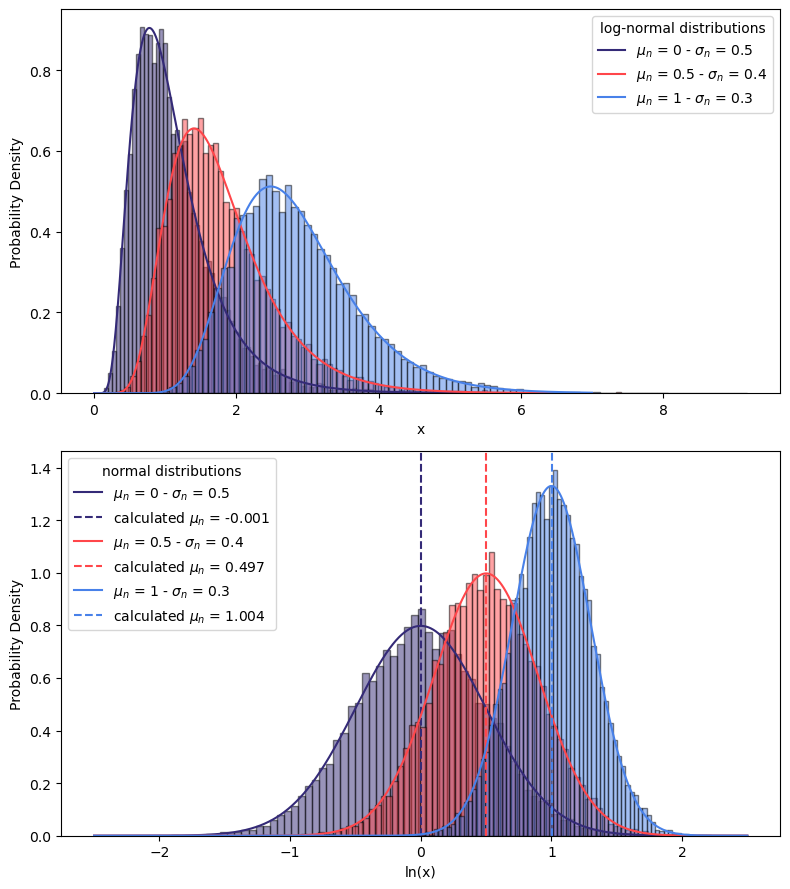

In [48]:
import matplotlib.pyplot as plt
# Matplotlib: digunakan untuk membuat visualisasi grafik 2D

import numpy as np
# NumPy: digunakan untuk operasi numerik dan array

from scipy.stats import norm, lognorm
# SciPy stats:
# - norm = distribusi normal (Gaussian)
# - lognorm = distribusi log-normal


colors = ['#342a77', '#ff464a', '#4881e9']
# daftar warna untuk membedakan tiap kurva

normal_mu = [0, 0.5, 1]
# daftar mean (μ) untuk distribusi log-normal (di domain log)

normal_sigma = [0.5, 0.4, 0.3]
# daftar standar deviasi (σ) untuk distribusi log-normal

x = np.arange(0.001, 7, .001)
# domain x untuk distribusi log-normal (harus > 0)

x1 = np.arange(-2.5, 2.5, .001)
# domain x untuk distribusi normal (log dari log-normal)


fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(8,9))
# membuat figure dengan 2 subplot vertikal


for mu_n, sigma_n, color in zip(normal_mu, normal_sigma, colors):
    # looping untuk setiap kombinasi mean, sigma, dan warna

    lognorm_pdf = lognorm.pdf(x, s=sigma_n, scale=np.exp(mu_n))
    # menghitung PDF distribusi log-normal teoritis

    r = lognorm.rvs(s=sigma_n, scale=np.exp(mu_n), size=15000)
    # membuat 15000 sampel acak dari distribusi log-normal

    ax1.plot(x, lognorm_pdf, color=color,
             label=r"$\mu_n$ = " + str(mu_n) + r" - $\sigma_n$ = " + str(sigma_n))
    # plot PDF log-normal teoritis

    ax1.hist(r, bins='auto', density=True,
             color=color, edgecolor='#000000', alpha=0.5)
    # histogram data sampel log-normal

    logr = np.log(r)
    # transformasi log dari data (mengubah log-normal → normal)

    normal_pdf = norm.pdf(x1, loc=mu_n, scale=sigma_n)
    # PDF distribusi normal teoritis dari data log

    ax2.plot(x1, normal_pdf, color=color,
             label=r"$\mu_n$ = " + str(mu_n) + r" - $\sigma_n$ = " + str(sigma_n))
    # plot PDF normal

    ax2.hist(logr, bins='auto', density=True,
             color=color, edgecolor='#000000', alpha=0.5)
    # histogram data setelah transformasi log

    my_mu = logr.mean()
    # menghitung mean dari data log (harusnya mendekati μ)

    ax2.axvline(x=my_mu, color=color, linestyle="--",
                label=r"calculated $\mu_n$ = " + str(round(my_mu,3)))
    # menampilkan garis mean hasil data

    my_sigma = logr.std()
    # menghitung standar deviasi dari data log

    print("Expected mean: " + str(mu_n) + " - Calculated mean: " + str(round(my_mu,3)))
    # membandingkan mean teoritis vs hasil sampel

    print("Expected std.dev.: " + str(sigma_n) + " - Calculated std.dev.: " + str(round(my_sigma,3)))
    # membandingkan standar deviasi teoritis vs hasil sampel


ax1.legend(title="log-normal distributions")
# legenda untuk subplot log-normal

ax1.set_xlabel('x')
# label sumbu x subplot 1

ax1.set_ylabel('Probability Density')
# label sumbu y subplot 1


ax2.legend(title="normal distributions")
# legenda untuk subplot normal

ax2.set_xlabel('ln(x)')
# label sumbu x subplot 2 (log domain)

ax2.set_ylabel('Probability Density')
# label sumbu y subplot 2


fig.tight_layout()
# merapikan layout agar tidak tumpang tindih

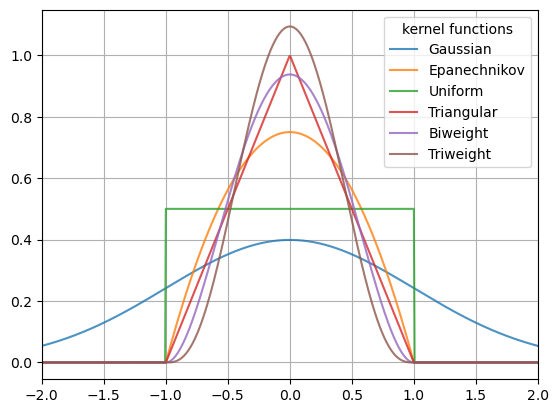

In [50]:
from statsmodels.nonparametric.kde import KDEUnivariate
# Statsmodels KDE: digunakan untuk estimasi density (Kernel Density Estimation) secara non-parametrik

import matplotlib.pyplot as plt
# Matplotlib: untuk membuat grafik

import numpy as np
# NumPy: untuk array dan operasi numerik


kernels = ['gau', 'epa', 'uni', 'tri', 'biw', 'triw']
# daftar jenis kernel yang digunakan dalam KDE:
# gau = Gaussian, epa = Epanechnikov, uni = Uniform, tri = Triangular,
# biw = Biweight, triw = Triweight

kernels_names = ['Gaussian', 'Epanechnikov', 'Uniform', 'Triangular', 'Biweight', 'Triweight']
# nama lengkap kernel untuk label plot

positions = np.arange(1, 9, 1)
# array posisi (tidak terlalu berpengaruh di kode ini, hanya variabel tambahan)


fig, ax = plt.subplots()
# membuat figure dan axis untuk plotting


for kernel, kernel_name, pos in zip(kernels, kernels_names, positions):
    # looping untuk setiap jenis kernel

    kde = KDEUnivariate([0])
    # membuat objek KDE dengan satu titik data (0) sebagai dasar distribusi

    kde.fit(kernel=kernel, bw=1, fft=False, gridsize=2**10)
    # melakukan fitting KDE:
    # - kernel = jenis kernel
    # - bw = bandwidth (lebar smoothing)
    # - fft=False = tidak memakai FFT
    # - gridsize = resolusi kurva KDE

    ax.plot(kde.support, kde.density,
            label=kernel_name,
            linewidth=1.5,
            alpha=0.8)
    # plot hasil density estimation dari kernel tersebut


ax.set_xlim(-2, 2)
# membatasi sumbu x agar fokus di sekitar distribusi

ax.grid()
# menampilkan grid pada plot

ax.legend(title='kernel functions')
# menampilkan legenda dengan judul

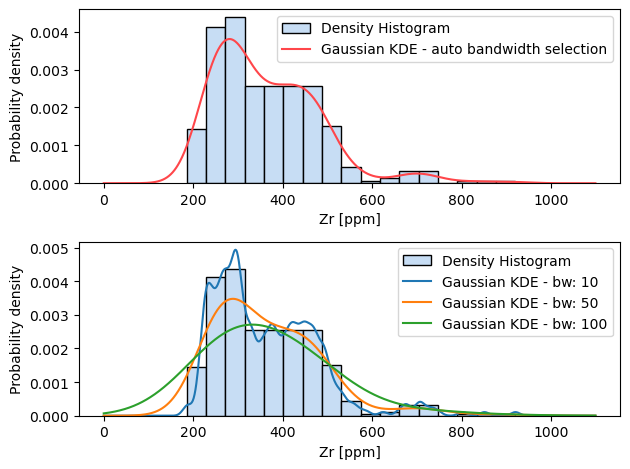

In [51]:
from statsmodels.nonparametric.kde import KDEUnivariate
# Statsmodels KDEUnivariate: digunakan untuk estimasi kepadatan probabilitas (KDE) secara non-parametrik

import pandas as pd
# Pandas: untuk membaca dan mengolah data tabel (Excel, CSV, dll)

import numpy as np
# NumPy: untuk array numerik dan operasi matematis

import matplotlib.pyplot as plt
# Matplotlib: untuk membuat grafik dan visualisasi data


my_dataset = pd.read_excel('Smith_glass_post_NYT_data.xlsx', sheet_name='Supp_traces')
# membaca data Excel dari sheet "Supp_traces"

x = my_dataset.Zr
# mengambil kolom Zr sebagai data utama

x_eval = np.arange(0, 1100, 1)
# membuat grid nilai x untuk evaluasi kurva KDE


fig = plt.figure()
# membuat figure untuk plotting


ax1 = fig.add_subplot(2, 1, 1)
# subplot pertama (2 baris, 1 kolom, posisi 1)

ax1.hist(x, bins='auto', density=True,
         label='Density Histogram',
         color='#c7ddf4',
         edgecolor='#000000')
# histogram distribusi data Zr (estimasi distribusi empiris)

kde = KDEUnivariate(x)
# membuat objek KDE dari data Zr

kde.fit()
# fitting KDE dengan bandwidth otomatis (default)

my_kde = kde.evaluate(x_eval)
# menghitung nilai KDE pada grid x_eval

ax1.plot(x_eval, my_kde,
         linewidth=1.5,
         color='#ff464a',
         label='Gaussian KDE - auto bandwidth selection')
# plot hasil KDE dengan bandwidth otomatis

ax1.set_xlabel('Zr [ppm]')
# label sumbu x subplot 1

ax1.set_ylabel('Probability density')
# label sumbu y subplot 1

ax1.legend()
# menampilkan legenda subplot 1


ax2 = fig.add_subplot(2, 1, 2)
# subplot kedua (untuk membandingkan bandwidth)

ax2.hist(x, bins="auto", density=True,
         label='Density Histogram',
         color='#c7ddf4',
         edgecolor='#000000')
# histogram yang sama untuk pembanding

for my_bw in [10, 50, 100]:
    # looping beberapa nilai bandwidth untuk melihat efek smoothing

    kde = KDEUnivariate(x)
    # membuat KDE baru untuk setiap bandwidth

    kde.fit(bw=my_bw)
    # fitting KDE dengan bandwidth tertentu

    my_kde = kde.evaluate(x_eval)
    # menghitung KDE pada grid x_eval

    ax2.plot(x_eval, my_kde,
             linewidth=1.5,
             label='Gaussian KDE - bw: ' + str(my_bw))
    # plot KDE untuk setiap bandwidth

ax2.set_xlabel('Zr [ppm]')
# label sumbu x subplot 2

ax2.set_ylabel('Probability density')
# label sumbu y subplot 2

ax2.legend()
# menampilkan legenda subplot 2


fig.tight_layout()
# merapikan layout agar tidak saling bertabrakan

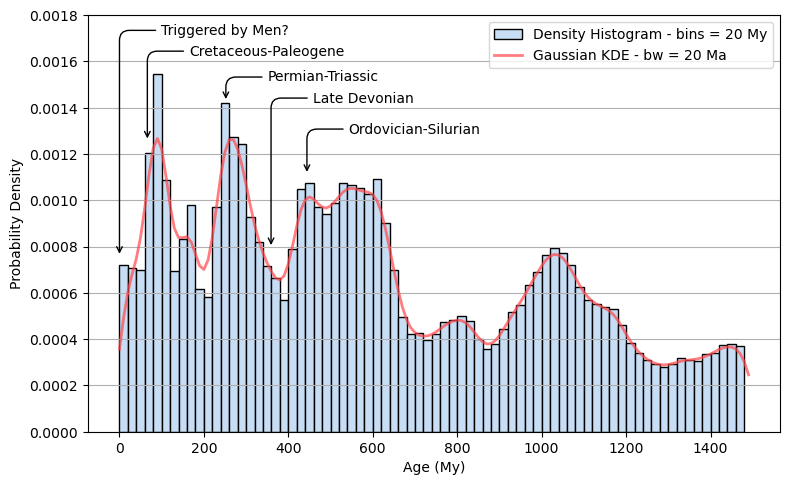

In [ ]:
import pandas as pd
# Pandas: digunakan untuk membaca, memfilter, dan mengolah data berbentuk tabel (Excel/CSV)

import matplotlib.pyplot as plt
# Matplotlib pyplot: digunakan untuk membuat grafik dan visualisasi data

import numpy as np
# NumPy: digunakan untuk operasi numerik seperti array dan pembuatan grid nilai

from statsmodels.nonparametric.kde import KDEUnivariate
# KDEUnivariate (statsmodels): digunakan untuk estimasi density (KDE) tanpa asumsi distribusi tertentu

# import Zircon data from Puetz (2010)
# mengambil data umur zircon dari file Excel dan memilih subset data yang valid
my_data = pd.read_excel('1-s2.0-S1674987117302141-mmc1.xlsx', sheet_name='Data')
# membaca file Excel dan mengambil sheet bernama "Data"

my_data = my_data[(my_data.age206Pb_238U > 0) & (my_data.age206Pb_238U < 1500)]
# filter data agar hanya umur yang masuk akal (0–1500 juta tahun)

my_sample = my_data.age206Pb_238U
# mengambil kolom umur sebagai sampel utama

# Plot the Density Histogram
# membuat histogram sebagai estimasi distribusi empiris data
fig, ax = plt.subplots(figsize=(8,5))
# membuat figure dan axis dengan ukuran tertentu

bins = np.arange(0, 1500, 20)
# membuat bin histogram setiap 20 juta tahun

ax.hist(my_sample, bins,
        color='#c7ddf4',
        edgecolor='k',
        density=True,
        label='Density Histogram - bins = 20 My')
# histogram normalisasi (density=True) untuk melihat probabilitas

# Compute and plot the KDE
# menghitung dan memplot kurva estimasi density (KDE)
age_eval = np.arange(0, 1500, 10)
# grid umur untuk evaluasi KDE setiap 10 juta tahun

kde = KDEUnivariate(my_sample)
# membuat objek KDE dari data umur zircon

kde.fit(bw=20)
# fitting KDE dengan bandwidth 20 Ma (mengontrol smoothing)

pdf = kde.evaluate(age_eval)
# menghitung nilai PDF hasil KDE pada grid age_eval

ax.plot(age_eval, pdf,
        label='Gaussian KDE - bw = 20 Ma',
        linewidth=2,
        alpha=0.7,
        color='#ff464a')
# plot hasil KDE sebagai kurva distribusi halus


# Adjust diagram parameters
# pengaturan tampilan grafik

ax.set_ylim(0, 0.0018)
# membatasi sumbu y agar fokus pada densitas kecil

ax.set_xlabel('Age (My)')
# label sumbu x (umur dalam juta tahun)

ax.set_ylabel('Probability Density')
# label sumbu y (densitas probabilitas)

ax.legend()
# menampilkan legenda grafik

ax.grid(axis='y')
# menambahkan grid hanya pada arah y


# Plot mass extinction annotations
# menambahkan anotasi peristiwa kepunahan massal

mass_extinction_age = [444, 359, 252, 66, 0]
# daftar umur kejadian kepunahan massal

pdf_mass_extinction_age = kde.evaluate(mass_extinction_age)
# menghitung nilai KDE pada titik-titik tersebut

mass_extincyion_name = [
    "Ordovician-Silurian",
    "Late Devonian",
    "Permian-Triassic",
    "Cretaceous-Paleogene",
    "Triggered by Men?"
]
# nama-nama peristiwa kepunahan

y_offsets = [0.0001, 0.0001, 0.0002, 0.0002, 0.0004]
# offset vertikal agar label tidak menempel kurva

y_texts = [30, 105, 15, 62, 160]
# posisi teks anotasi pada sumbu offset

x_texts = [30, 30, 30, 30, 30]
# posisi horizontal teks anotasi


for x, y, name, x_text, y_text, y_offset in zip(
        mass_extinction_age,
        pdf_mass_extinction_age,
        mass_extincyion_name,
        x_texts,
        y_texts,
        y_offsets):
    # loop untuk setiap event kepunahan

    ax.annotate(name,
                xy=(x, y + y_offset),
                xycoords='data',
                xytext=(x_text, y_text),
                textcoords='offset points',
                arrowprops=dict(arrowstyle="->",
                                connectionstyle="angle, angleA=0, angleB=90, rad=10"))
    # menambahkan teks + panah ke lokasi event pada grafik


fig.tight_layout()
# merapikan layout agar tidak saling bertabrakan

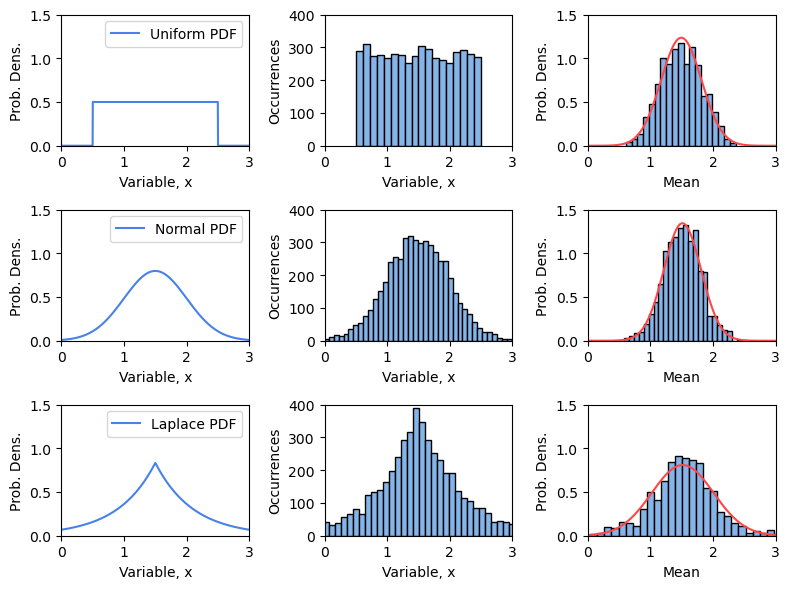

In [2]:
import numpy as np
# NumPy: digunakan untuk operasi array, numerik, dan pembuatan grid data

import scipy.stats as stats
# SciPy stats: menyediakan distribusi probabilitas (uniform, normal, laplace), fungsi PDF, dan sampling random (RVS)

import matplotlib.pyplot as plt
# Matplotlib pyplot: digunakan untuk membuat visualisasi grafik


fig = plt.figure(figsize=(8,6))
# membuat figure utama dengan ukuran 8x6 inci


dists = [
    stats.uniform(loc=0.5, scale=2),
    stats.norm(loc=1.5, scale=0.5),
    stats.laplace(loc=1.5, scale=0.6)
]
# membuat tiga distribusi probabilitas:
# uniform (sebaran rata), normal (Gaussian), dan Laplace (lebih tajam di pusat)

names = ['Uniform', 'Normal', 'Laplace']
# nama masing-masing distribusi untuk label plot

x = np.linspace(0, 3, 1000)
# membuat domain x dari 0 sampai 3 dengan resolusi tinggi


for i, (dist, name) in enumerate(zip(dists, names)):
    # looping setiap distribusi dan namanya sekaligus

    pdf = dist.pdf(x)
    # menghitung Probability Density Function (PDF) pada setiap nilai x

    ax1 = fig.add_subplot(3, 3, 3*i+1)
    # subplot kolom pertama: grafik PDF

    ax1.plot(x, pdf, color='#4881e9', label= name + ' PDF')
    # plot kurva PDF

    ax1.set_xlim(0,3)
    # batas sumbu x

    ax1.set_ylim(0,1.5)
    # batas sumbu y

    ax1.set_xlabel('Variable, x')
    # label sumbu x

    ax1.set_ylabel('Prob. Dens.')
    # label sumbu y

    ax1.legend()
    # menampilkan legenda


    rnd = dist.rvs(size=5000)
    # mengambil 5000 sampel acak dari distribusi (random variable simulation)

    ax2 = fig.add_subplot(3, 3, 3*i+2)
    # subplot kolom kedua: histogram sampel

    ax2.hist(rnd, bins='auto', color='#84b4e8', edgecolor='#000000')
    # histogram distribusi hasil sampling

    ax2.set_xlim(0,3)
    # batas sumbu x

    ax2.set_ylim(0,400)
    # batas sumbu y

    ax2.set_xlabel('Variable, x')
    # label sumbu x

    ax2.set_ylabel('Occurrences')
    # label jumlah kemunculan data


    ax3 = fig.add_subplot(3, 3, 3*i+3)
    # subplot kolom ketiga: distribusi rata-rata sampel (CLT illustration)

    mean_dist = []
    # list untuk menyimpan hasil rata-rata sampel

    for _ in range(1000):
        # melakukan sampling berulang untuk melihat distribusi mean

        mean_dist.append(dist.rvs(size=3).mean())
        # mengambil 3 sampel acak lalu dihitung rata-ratanya

    mean_dist = np.array(mean_dist)
    # mengubah list menjadi array NumPy

    ax3.hist(mean_dist, density=True, bins='auto',
             color='#84b4e8', edgecolor='#000000')
    # histogram distribusi mean (normalisasi ke density)

    normal = stats.norm(loc= mean_dist.mean(), scale= mean_dist.std())
    # membuat distribusi normal yang di-fit dari mean sampling

    ax3.plot(x, normal.pdf(x), color='#ff464a')
    # overlay kurva normal sebagai pembanding

    ax3.set_xlim(0,3)
    # batas sumbu x

    ax3.set_ylim(0,1.5)
    # batas sumbu y

    ax3.set_xlabel('Mean')
    # label sumbu x

    ax3.set_ylabel('Prob. Dens.')
    # label sumbu y


fig.tight_layout()
# merapikan layout agar subplot tidak saling bertumpuk